In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import joblib

In [6]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\dataset\EcoPackAI_materials.csv"
)

df.head()

,material_id,material_name,strength,weight_capacity,cost,biodegradability_score,co2_score,recyclability_percent
0,1,Corrugated Cardboard,3,25,2,9,3,85
1,2,Kraft Paper,2,15,1,8,4,80
2,3,Recycled Paper,2,12,1,9,3,90
3,4,Molded Pulp,2,10,2,10,2,95
4,5,Bagasse,3,20,3,10,2,85


In [7]:
print(df.columns.tolist())

['material_id', 'material_name', 'strength', 'weight_capacity', 'cost', 'biodegradability_score', 'co2_score', 'recyclability_percent']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   material_id             54 non-null     int64 
 1   material_name           54 non-null     object
 2   strength                54 non-null     int64 
 3   weight_capacity         54 non-null     int64 
 4   cost                    54 non-null     int64 
 5   biodegradability_score  54 non-null     int64 
 6   co2_score               54 non-null     int64 
 7   recyclability_percent   54 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 3.5+ KB


In [9]:
df.describe()

,material_id,strength,weight_capacity,cost,biodegradability_score,co2_score,recyclability_percent
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,27.500000,2.129630,23.666667,3.814815,8.203704,3.648148,78.444444
std,15.732133,0.778152,20.792778,2.047309,1.496910,1.429572,11.364736
min,1.000000,1.000000,3.000000,1.000000,4.000000,1.000000,50.000000
25%,14.250000,2.000000,8.500000,2.000000,7.250000,3.000000,70.000000
50%,27.500000,2.000000,18.000000,3.000000,9.000000,3.000000,80.000000
75%,40.750000,3.000000,29.500000,5.000000,9.000000,4.000000,85.000000
max,54.000000,3.000000,90.000000,10.000000,10.000000,7.000000,100.000000


In [10]:
df.isnull().sum()

material_id               0
material_name             0
strength                  0
weight_capacity           0
cost                      0
biodegradability_score    0
co2_score                 0
recyclability_percent     0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
X = df[
    [
        "strength",
        "weight_capacity",
        "biodegradability_score",
        "recyclability_percent"
    ]
]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

y_cost = df["cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cost,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Cost model trained successfully!")

Cost model trained successfully!


In [16]:
predictions = rf.predict(X_test)

print(predictions[:10])

[6.36  4.955 8.91  1.56  3.69  2.23  1.775 2.47  2.81  1.72 ]


In [17]:
import os

os.makedirs(
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models",
    exist_ok=True
)

In [72]:
import joblib

joblib.dump(
    rf,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\rf_cost.pkl"
)

print("Cost model saved successfully!")

Cost model saved successfully!


In [38]:
from xgboost import XGBRegressor

y_co2 = df["co2_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_co2,
    test_size=0.2,
    random_state=42
)

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

print("CO₂ model trained successfully!")

CO₂ model trained successfully!


In [73]:
joblib.dump(
    xgb_model,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\xgb_co2.pkl"
)

print("CO₂ model saved successfully!")

CO₂ model saved successfully!


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

joblib.dump(
    scaler,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [22]:
print(df.columns.tolist())

['material_id', 'material_name', 'strength', 'weight_capacity', 'cost', 'biodegradability_score', 'co2_score', 'recyclability_percent']


In [23]:
import os

print(os.listdir(r"C:\Users\udit\OneDrive\Desktop\Ecopack\models"))

['.ipynb_checkpoints', 'rf_cost.pkl', 'scaler.pkl', 'Untitled.ipynb', 'xgb_co2.pkl']


In [24]:
import numpy as np
import pandas as pd
import psycopg2

print("Environment ready")


Environment ready


In [25]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="ecopackai",   # No leading space
    user="postgres",
    password="udithssql"
)

print("Connected to PostgreSQL server successfully")

Connected to PostgreSQL server successfully


In [26]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\dataset\EcoPackAI_materials.csv"
)

print(df.head())

   material_id         material_name  strength  weight_capacity  cost  \
0            1  Corrugated Cardboard         3               25     2   
1            2           Kraft Paper         2               15     1   
2            3        Recycled Paper         2               12     1   
3            4           Molded Pulp         2               10     2   
4            5               Bagasse         3               20     3   

   biodegradability_score  co2_score  recyclability_percent  
0                       9          3                     85  
1                       8          4                     80  
2                       9          3                     90  
3                      10          2                     95  
4                      10          2                     85  


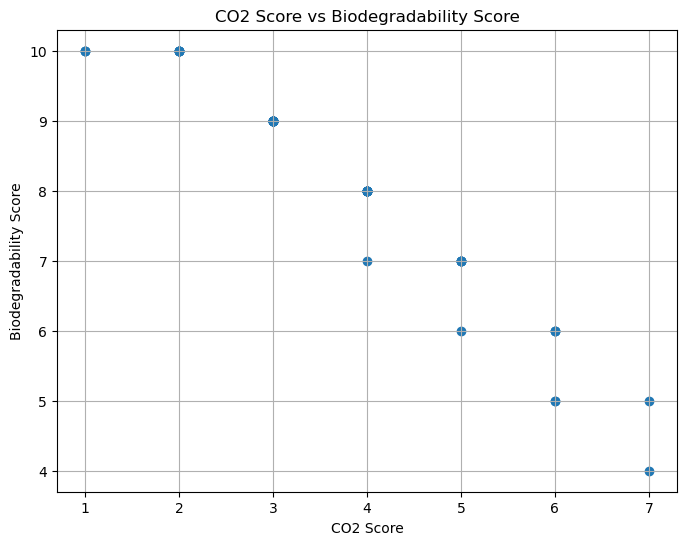

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["co2_score"],
    df["biodegradability_score"]
)

plt.xlabel("CO2 Score")
plt.ylabel("Biodegradability Score")
plt.title("CO2 Score vs Biodegradability Score")

plt.grid(True)

plt.show()

In [28]:
X = df[
    [
        "strength",
        "weight_capacity",
        "biodegradability_score",
        "recyclability_percent"
    ]
]

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

y_cost = df["cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cost,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Cost model trained successfully!")

Cost model trained successfully!


In [30]:
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (43, 4)
Testing data size: (11, 4)


In [31]:
print(df.shape)

(54, 8)


In [41]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (43, 4)
X_test shape: (11, 4)
y_train shape: (43,)
y_test shape: (11,)


In [43]:
X

,strength,weight_capacity,biodegradability_score,recyclability_percent
0,3,25,9,85
1,2,15,8,80
2,2,12,9,90
3,2,10,10,95
4,3,20,10,85
5,2,8,8,70
6,1,5,9,60
7,3,30,10,85
8,3,18,10,80
9,3,40,9,75


In [44]:
X_train

,strength,weight_capacity,biodegradability_score,recyclability_percent
8,3,18,10,80
26,2,10,10,75
6,1,5,9,60
34,2,25,8,70
4,3,20,10,85
37,2,15,7,70
24,2,20,8,75
45,2,22,9,85
33,3,30,7,85
50,3,35,8,75


In [46]:
y_train

8     2
26    2
6     3
34    4
4     2
37    5
24    4
45    3
33    4
50    4
15    1
9     3
16    2
30    5
36    3
25    1
11    5
0     3
47    3
27    3
31    3
40    4
29    4
46    3
1     4
21    6
2     3
41    3
39    6
35    3
23    4
43    5
10    3
22    3
18    3
53    3
20    7
7     2
42    3
14    1
28    7
51    5
38    6
Name: co2_score, dtype: int64

In [47]:
y_test

19    6
49    5
48    6
12    4
44    4
5     4
17    3
52    3
3     2
32    4
13    3
Name: co2_score, dtype: int64

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [49]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [50]:
import numpy as np
print(np.round(X_train_scaled.mean(axis=0), 6))
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[ 0.  0. -0. -0.]
[ 2.01389293e-16  4.64744522e-17 -3.45976477e-16 -4.95727490e-16]
[1. 1. 1. 1.]


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf_cost = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_cost.fit(X_train, y_train)
y_cost_pred = rf_cost.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_cost_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_cost_pred))
r2 = r2_score(y_test, y_cost_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.10181818181818175
RMSE: 0.20049937655763417
R2: 0.9723625


In [56]:
from xgboost import XGBRegressor

xgb_co2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_co2.fit(X_train_scaled, y_train)

y_co2_pred = xgb_co2.predict(X_test_scaled)


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_co2_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_co2_pred))
r2 = r2_score(y_test, y_co2_pred)

print("CO2 MAE:", mae)
print("CO2 RMSE:", rmse)
print("CO2 R2:", r2)


CO2 MAE: 0.09907898306846619
CO2 RMSE: 0.24235910058364152
CO2 R2: 0.9596176743507385


In [58]:
print(y_train.head())
print(X_train_scaled.mean())

8     2
26    2
6     3
34    4
4     2
Name: co2_score, dtype: int64
-1.4716909861310214e-16


In [59]:
# normalize strength (High=3 best → invert)
strength_norm = (df['strength'] - df['strength'].min()) / (
    df['strength'].max() - df['strength'].min()
)
strength_norm = 1 - strength_norm

# normalize recyclability (higher is better → invert)
recycle_norm = (df['recyclability_percent'] - df['recyclability_percent'].min()) / (
    df['recyclability_percent'].max() - df['recyclability_percent'].min()
)
recycle_norm = 1 - recycle_norm

# normalize biodegradability (higher is better → invert)
bio_norm = (df['biodegradability_score'] - df['biodegradability_score'].min()) / (
    df['biodegradability_score'].max() - df['biodegradability_score'].min()
)
bio_norm = 1 - bio_norm


In [60]:
suitability = (
    0.4 * strength_norm +
    0.3 * recycle_norm +
    0.3 * bio_norm
)

In [61]:
cost_norm = (df['cost'] - df['cost'].min()) / (df['cost'].max() - df['cost'].min())

co2_norm = (df['co2_score'] - df['co2_score'].min()) / (df['co2_score'].max() - df['co2_score'].min())

In [62]:
df['final_score'] = (
    0.4 * cost_norm +
    0.4 * co2_norm +
    0.2 * suitability
)

In [63]:
ranked_materials = df.sort_values('final_score')
ranked_materials[['material_id', 'final_score']].head()

,material_id,final_score
3,4,0.157111
16,17,0.169956
4,5,0.173556
25,26,0.184444
14,15,0.185333


In [64]:
ranked_materials = df.sort_values('final_score').reset_index(drop=True)

ranked_materials['rank'] = ranked_materials.index + 1

In [65]:
ranked_materials[['rank', 'material_id', 'final_score']].head()

,rank,material_id,final_score
0,1,4,0.157111
1,2,17,0.169956
2,3,5,0.173556
3,4,26,0.184444
4,5,15,0.185333


In [66]:
import pickle

# Save trained models
pickle.dump(rf_cost, open("rf_cost.pkl", "wb"))
pickle.dump(xgb_co2, open("xgb_co2.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [67]:
import os
os.listdir()

['.ipynb_checkpoints',
 'rf_cost.pkl',
 'scaler.pkl',
 'Untitled.ipynb',
 'xgb_co2.pkl']

In [69]:
import os

print(os.path.exists(r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\rf_cost.pkl"))
print(os.path.exists(r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\xgb_co2.pkl"))
print(os.path.exists(r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\scaler.pkl"))

True
True
True


In [71]:
import joblib

joblib.dump(
    rf,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\rf_cost.pkl"
)

print("Cost model saved successfully!")

Cost model saved successfully!


In [74]:
joblib.dump(
    xgb_model,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\xgb_co2.pkl"
)

print("CO₂ model saved successfully!")

CO₂ model saved successfully!


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

joblib.dump(
    scaler,
    r"C:\Users\udit\OneDrive\Desktop\Ecopack\models\scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
